# Entrega Final — NLP & Deep Learning
## Clasificación de Sentimiento en Reseñas de Películas (IMDB)

---

* Autor: Riveros Lobos Rodolfo Gabriel
* Curso: Data Science III: NLP & Deep Learning aplicado a Ciencia de Datos Flex

---

## 1.Qué se evalúa

Se implementa un pipeline completo de Procesamiento de
Lenguaje Natural (NLP) y Deep Learning aplicado a un problema real
de clasificación de texto.

El pipeline cubre las siguientes etapas:

- Selección y justificación del dataset
- Análisis exploratorio de datos (EDA)
- Preprocesamiento textual: limpieza con Regex, tokenización
  y lematización comparativa con NLTK y spaCy
- Representación numérica con TF-IDF y reflexión conceptual
- Modelado con una red neuronal densa (TextClassifier)
  implementada en PyTorch, entrenada con Adam, CrossEntropyLoss
  y Early Stopping
- Integración de un modelo preentrenado de HuggingFace
  para comparación y análisis
- Evaluación completa con Accuracy, Precision, Recall,
  F1-Score, Matriz de Confusión y Curva ROC
- Conclusiones, limitaciones y propuesta de mejoras

El objetivo es demostrar dominio técnico del pipeline NLP,
capacidad de documentación clara y mentalidad orientada
a entornos productivos reales.

## 2.Instalación y carga de data
- Nombre: IMDB Movie Reviews
- Fuente: HuggingFace Datasets (librería `datasets`)
- Tipo: Clasificación binaria (sentimiento positivo vs negativo)

### 2.1 Dataset: Justificación de la elección

El dataset seleccionado es IMDB Movie Reviews, disponible
públicamente a través de HuggingFace Datasets.

Se eligió este dataset por las siguientes razones:

Tipo de problema: clasificación binaria de sentimiento
(positivo / negativo), que permite enfocarse en el pipeline
técnico completo sin la complejidad adicional de múltiples
clases ni desbalance entre ellas.

Volumen: 50.000 reseñas en total, superando ampliamente
el mínimo requerido de 2.000 registros.

Balance perfecto: 25.000 reseñas positivas y 25.000 negativas
(ratio 1.000), lo que elimina la necesidad de técnicas de
balanceo como SMOTE o class_weight, permitiendo que las
métricas de accuracy sean confiables e interpretables
directamente.

Soporte técnico: al ser el dataset de referencia en NLP para
clasificación de sentimiento, cuenta con amplia documentación,
modelos preentrenados disponibles y benchmarks públicos
para comparación.

Reproducibilidad: accesible directamente desde la librería
datasets de HuggingFace con una sola línea de código,
sin necesidad de descargas manuales ni procesamiento previo.


### 2.2 Evidencia de registros

Fuente     : HuggingFace Datasets — load_dataset("imdb")
Total      : 50.000 reseñas
Columnas   : text (reseña en texto libre), label (0/1)
Split      : 25.000 train / 25.000 test (original HuggingFace)

Distribución de clases:

  Negativo (label=0) : 25.000 reseñas — 50%
  Positivo (label=1)

In [ ]:
# ============================================================
# CELDA 1 — Instalación y carga del dataset
# ============================================================

!pip install datasets -q

import pandas as pd
import numpy as np
from datasets import load_dataset

# Semilla global de reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Cargar IMDB desde HuggingFace
dataset = load_dataset("imdb")

# Convertir a DataFrames
df_train = pd.DataFrame(dataset["train"])
df_test  = pd.DataFrame(dataset["test"])

# Dataset completo
df_full = pd.concat([df_train, df_test], ignore_index=True)
df_full["label_name"] = df_full["label"].map({0: "Negativo", 1: "Positivo"})

# ── Evidencia 1: estructura
print("=== ESTRUCTURA DEL DATASET ===")
print(f"Columnas     : {df_full.columns.tolist()}")
print(f"Total filas  : {len(df_full):,}")
print(f"Tipo de label: {df_full['label'].dtype}")

# ── Evidencia 2: distribución de clases
print("\n=== DISTRIBUCIÓN DE CLASES ===")
print(df_full["label_name"].value_counts().to_string())
print(f"\nTotal registros: {len(df_full):,}")
print(f"Ratio de balance: {df_full['label_name'].value_counts().min() / df_full['label_name'].value_counts().max():.3f}")

# ── Evidencia 3: muestra de registros
print("\n=== MUESTRA DE REGISTROS ===")
display(df_full[["label_name", "text"]].sample(3, random_state=RANDOM_STATE))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


=== ESTRUCTURA DEL DATASET ===
Columnas     : ['text', 'label', 'label_name']
Total filas  : 50,000
Tipo de label: int64

=== DISTRIBUCIÓN DE CLASES ===
label_name
Negativo    25000
Positivo    25000

Total registros: 50,000
Ratio de balance: 1.000

=== MUESTRA DE REGISTROS ===


,label_name,text
33553,Negativo,Forget what I said about Emeril. Rachael Ray i...
9427,Negativo,Former private eye-turned-security guard ditch...
199,Negativo,Mann photographs the Alberta Rocky Mountains i...


## 3.EDA - Distribución de Clases
Vamos con dos análisis: distribución de clases y palabras frecuentes.

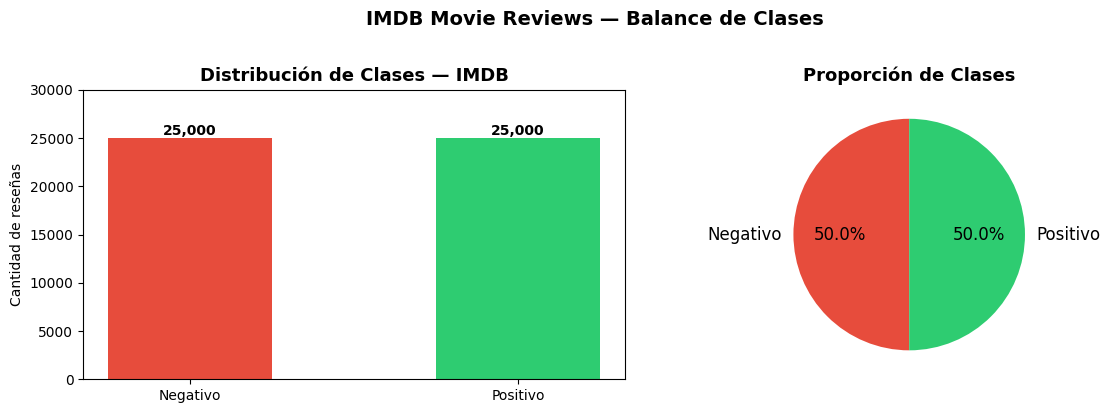

Total registros : 50,000
Negativo        : 25,000 (50.0%)
Positivo        : 25,000 (50.0%)
Ratio de balance: 1.000


In [ ]:
# ============================================================
# CELDA 2 — EDA: Distribución de clases
# ============================================================

import matplotlib.pyplot as plt

counts = df_full["label_name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
axes[0].bar(
    counts.index,
    counts.values,
    color=["#e74c3c", "#2ecc71"],
    width=0.5
)
axes[0].set_title(
    "Distribución de Clases — IMDB",
    fontsize=13, fontweight="bold"
)
axes[0].set_ylabel("Cantidad de reseñas")
axes[0].set_ylim(0, 30000)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f"{v:,}",
                 ha="center", fontweight="bold")

# Torta
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"],
    startangle=90,
    textprops={"fontsize": 12}
)
axes[1].set_title(
    "Proporción de Clases",
    fontsize=13, fontweight="bold"
)

plt.suptitle(
    "IMDB Movie Reviews — Balance de Clases",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("eda_distribucion_clases.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Total registros : {len(df_full):,}")
print(f"Negativo        : {counts['Negativo']:,} ({counts['Negativo']/len(df_full)*100:.1f}%)")
print(f"Positivo        : {counts['Positivo']:,} ({counts['Positivo']/len(df_full)*100:.1f}%)")
print(f"Ratio de balance: {counts.min()/counts.max():.3f}")

## 3.1 EDA - Palabras más frecuentes por clase

⏳ Calculando frecuencias...
✅ Listo


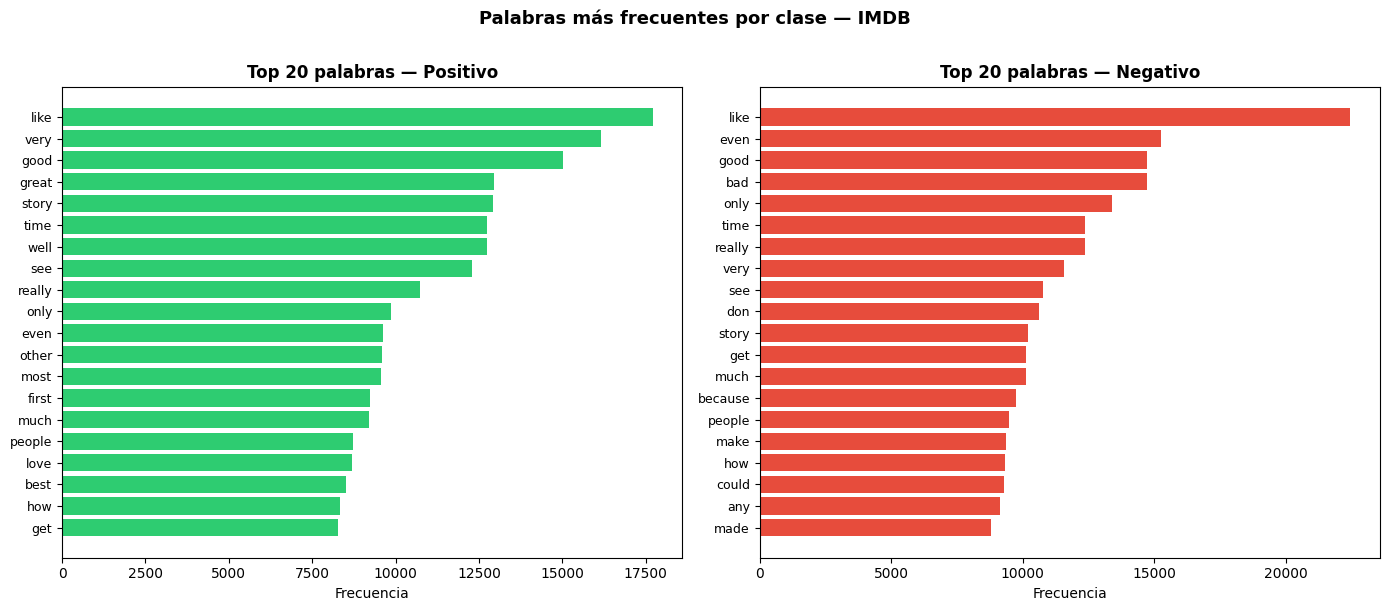


TOP 10 — POSITIVO:
  like                 17,714
  very                 16,169
  good                 15,025
  great                12,964
  story                12,934
  time                 12,752
  well                 12,729
  see                  12,276
  really               10,739
  only                 9,865

TOP 10 — NEGATIVO:
  like                 22,458
  even                 15,254
  good                 14,728
  bad                  14,726
  only                 13,376
  time                 12,358
  really               12,355
  very                 11,558
  see                  10,753
  don                  10,622


In [ ]:
# ============================================================
# CELDA 3 — EDA: Palabras más frecuentes por clase
# ============================================================

from collections import Counter
import re

# Stopwords básicas para EDA — sin NLTK aún
# El preprocesamiento completo viene en Sección 4
STOPWORDS_EDA = {
    "the","a","an","and","or","but","in","on","at","to","for",
    "of","with","is","was","it","this","that","as","be","are",
    "were","has","have","had","not","from","by","his","her","he",
    "she","they","we","you","i","my","its","our","their","been",
    "so","if","about","up","out","do","no","can","just","more",
    "one","all","would","there","what","when","which","who","will",
    "also","than","then","into","some","me","him","them","said",
    "br","film","movie","films","movies"  # artefactos IMDB
}

def get_top_words(df, label_val, n=20):
    texts = df[df["label"] == label_val]["text"].str.lower()
    words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', text)
        words.extend([w for w in tokens if w not in STOPWORDS_EDA])
    return Counter(words).most_common(n)

print("⏳ Calculando frecuencias...")
top_pos = get_top_words(df_full, 1)
top_neg = get_top_words(df_full, 0)
print("✅ Listo")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top_words, title, color in zip(
    axes,
    [top_pos, top_neg],
    ["Top 20 palabras — Positivo", "Top 20 palabras — Negativo"],
    ["#2ecc71", "#e74c3c"]
):
    words, freqs = zip(*top_words)
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle(
    "Palabras más frecuentes por clase — IMDB",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("eda_palabras_frecuentes.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Imprimir top 10 por clase para el Doc
print("\nTOP 10 — POSITIVO:")
for w, f in top_pos[:10]:
    print(f"  {w:<20} {f:,}")

print("\nTOP 10 — NEGATIVO:")
for w, f in top_neg[:10]:
    print(f"  {w:<20} {f:,}")

## 3.2. EDA — Análisis Exploratorio de Datos

### 3.1 Distribución de clases

El dataset IMDB presenta un balance perfecto entre clases:

  Negativo (label=0) : 25.000 reseñas — 50%
  Positivo (label=1) : 25.000 reseñas — 50%
  Ratio de balance   : 1.000

Este balance tiene implicancias técnicas directas:
- La accuracy es una métrica confiable e interpretable
- No se requieren técnicas de balanceo (SMOTE, class_weight)
- El modelo no tiene incentivo para favorecer ninguna clase
  por frecuencia

[Insertar imagen: eda_distribucion_clases.png]


### 3.2 Palabras más frecuentes por clase

Se calcularon las palabras más frecuentes por clase
aplicando una limpieza básica con Regex y eliminación
de stopwords generales.

TOP 10 — Clase POSITIVA:
  like (17.714) · very (16.169) · good (15.025)
  great (12.964) · story (12.934) · time (12.752)
  well (12.729) · see (12.276) · really (10.739)
  only (9.865)

TOP 10 — Clase NEGATIVA:
  like (22.458) · even (15.254) · good (14.728)
  bad (14.726) · only (13.376) · time (12.358)
  really (12.355) · very (11.558) · see (10.753)
  don (10.622)


Observaciones:

1. Alta superposición entre clases: palabras como "like",
   "good", "time" y "very" aparecen en ambas listas con
   frecuencias similares. Esto es esperable: el conteo
   simple no distingue sentimiento porque las palabras
   más frecuentes son genéricas por naturaleza.

2. Señales discriminativas presentes: "great", "story"
   y "well" concentran frecuencia en reseñas positivas,
   mientras que "bad", "even" y "only" son más frecuentes
   en negativas. "even" y "only" actúan como marcadores
   de decepción ("not even worth watching", "only 20
   minutes in and I quit").

3. Artefacto detectado: "don" aparece como fragmento de
   "don't" debido a que la limpieza con Regex eliminó
   apóstrofes. Esto confirma que las negaciones se
   pierden en este nivel de preprocesamiento — limitación
   que se aborda en la Sección 4.

4. Motivación para TF-IDF: el conteo simple falla como
   representación porque no penaliza palabras genéricas.
   TF-IDF resuelve esto asignando mayor peso a términos
   frecuentes en pocos documentos — exactamente los que
   distinguen sentimiento. Este análisis justifica
   directamente la elección de TF-IDF en la Sección 5.

## 4.Preprocesamiento: Limpieza con Regex + Tokenización y Lematización
Limpieza con Regex, tokenización + lematización, y la tabla comparativa NLTK vs spaCy

In [ ]:
# ============================================================
# CELDA 4 — Instalación de dependencias NLP
# ============================================================

!pip install nltk spacy -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download("stopwords",  quiet=True)
nltk.download("wordnet",    quiet=True)
nltk.download("punkt",      quiet=True)
nltk.download("punkt_tab",  quiet=True)

print("✅ Dependencias listas")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Dependencias listas


### 4.1 Limpieza con Regex

In [ ]:
# ============================================================
# CELDA 5 — Limpieza con Regex
# ============================================================

import re

def clean_text(text: str) -> str:
    """
    Pipeline de limpieza textual con expresiones regulares.
    Cada paso tiene una justificación técnica específica.
    """
    # 1. Eliminar etiquetas HTML (frecuentes en IMDB: <br />, <i>)
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Eliminar URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 3. Eliminar menciones y hashtags
    text = re.sub(r'[@#]\w+', ' ', text)

    # 4. Conservar apóstrofes para preservar negaciones
    #    (don't, wasn't, couldn't)
    text = re.sub(r"[^a-zA-Z\s']", ' ', text)

    # 5. Normalizar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Convertir a minúsculas
    text = text.lower()

    return text

# Aplicar al dataset completo
df_full["text_clean"] = df_full["text"].apply(clean_text)

# Evidencia: antes vs después
print("=== EVIDENCIA: ORIGINAL vs LIMPIO ===\n")
for idx in [0, 10, 42]:
    print(f"--- Registro {idx} ---")
    print(f"ORIGINAL : {df_full['text'].iloc[idx][:150]}")
    print(f"LIMPIO   : {df_full['text_clean'].iloc[idx][:150]}")
    print()

=== EVIDENCIA: ORIGINAL vs LIMPIO ===

--- Registro 0 ---
ORIGINAL : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th
LIMPIO   : i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at 

--- Registro 10 ---
ORIGINAL : It was great to see some of my favorite stars of 30 years ago including John Ritter, Ben Gazarra and Audrey Hepburn. They looked quite wonderful. But 
LIMPIO   : it was great to see some of my favorite stars of years ago including john ritter ben gazarra and audrey hepburn they looked quite wonderful but that w

--- Registro 42 ---
ORIGINAL : WARNING: This review contains SPOILERS. Do not read if you don't want some points revealed to you before you watch the film.<br /><br />With a cast li
LIMPIO   : warning this review contains spoilers do not read if you don't want some points

### 4.2 Tokenización y Lematización: NLTK vs spaCy

In [ ]:
# ============================================================
# CELDA 6 — NLTK vs spaCy: funciones de preprocesamiento
# ============================================================

import spacy
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nlp          = spacy.load("en_core_web_sm")
lemmatizer   = WordNetLemmatizer()
stop_nltk    = set(stopwords.words("english"))

# --- Pipeline NLTK ---
def preprocess_nltk(text: str) -> str:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_nltk]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# --- Pipeline spaCy ---
def preprocess_spacy(text: str) -> str:
    doc    = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]
    return " ".join(tokens)

print("✅ Funciones definidas")

✅ Funciones definidas


### 4.3. Tabla Comparativa con Ejemplos

In [ ]:
# ============================================================
# CELDA 7 — Tabla comparativa NLTK vs spaCy
# ============================================================

# Casos seleccionados para mostrar diferencias reales
casos = [
    "The acting was not good, it was terrible and disappointing.",
    "She has the best performances I have ever seen in years.",
    "I couldn't stop watching, it was absolutely brilliant."
]

print("=" * 90)
print(f"{'ORIGINAL':<45} {'NLTK':<20} {'spaCy':<20}")
print("=" * 90)

comparacion = []

for texto in casos:
    limpio       = clean_text(texto)
    tokens_nltk  = preprocess_nltk(limpio).split()[:6]
    tokens_spacy = preprocess_spacy(limpio).split()[:6]

    print(f"\nOriginal : {texto}")
    print(f"Limpio   : {limpio}")
    print(f"NLTK     : {tokens_nltk}")
    print(f"spaCy    : {tokens_spacy}")

    comparacion.append({
        "original"   : texto,
        "nltk_tokens": " · ".join(tokens_nltk),
        "spacy_tokens": " · ".join(tokens_spacy)
    })

print("\n✅ Comparación completa")

# Diferencias clave para documentar
print("\n=== DIFERENCIAS CLAVE ===")
print("Caso 1 — 'not good':")
print(f"  NLTK : {preprocess_nltk(clean_text('not good'))}")
print(f"  spaCy: {preprocess_spacy(clean_text('not good'))}")

print("\nCaso 2 — 'performances' (plural irregular):")
print(f"  NLTK : {lemmatizer.lemmatize('performances')}")
print(f"  spaCy: {nlp('performances')[0].lemma_}")

print("\nCaso 3 — 'better' (comparativo):")
print(f"  NLTK : {lemmatizer.lemmatize('better')}")
print(f"  spaCy: {nlp('better')[0].lemma_}")

ORIGINAL                                      NLTK                 spaCy               

Original : The acting was not good, it was terrible and disappointing.
Limpio   : the acting was not good it was terrible and disappointing
NLTK     : ['acting', 'good', 'terrible', 'disappointing']
spaCy    : ['acting', 'good', 'terrible', 'disappointing']

Original : She has the best performances I have ever seen in years.
Limpio   : she has the best performances i have ever seen in years
NLTK     : ['best', 'performance', 'ever', 'seen', 'year']
spaCy    : ['good', 'performance', 'see', 'year']

Original : I couldn't stop watching, it was absolutely brilliant.
Limpio   : i couldn't stop watching it was absolutely brilliant
NLTK     : ['could', 'stop', 'watching', 'absolutely', 'brilliant']
spaCy    : ['stop', 'watch', 'absolutely', 'brilliant']

✅ Comparación completa

=== DIFERENCIAS CLAVE ===
Caso 1 — 'not good':
  NLTK : good
  spaCy: good

Caso 2 — 'performances' (plural irregular):
  NLTK :

### 4.4 Aplicación del preprocesamiento final

In [ ]:
# ============================================================
# CELDA 8 — Preprocesamiento final + muestra estratificada
# ============================================================

from tqdm import tqdm
tqdm.pandas()

# Muestra estratificada de 10.000 registros (5.000 por clase)
df_sample = (
    df_full
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(5000, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f"Muestra total   : {len(df_sample):,}")
print(f"Balance         : {df_sample['label'].value_counts().to_dict()}")

# Aplicar pipeline spaCy en batch (más eficiente)
def batch_preprocess_spacy(texts, batch_size=500):
    result = []
    docs   = nlp.pipe(
        texts,
        batch_size=batch_size,
        disable=["ner", "parser"]
    )
    for doc in docs:
        tokens = [
            t.lemma_.lower()
            for t in doc
            if t.is_alpha and not t.is_stop
        ]
        result.append(" ".join(tokens))
    return result

print("\n⏳ Aplicando preprocesamiento con spaCy...")
df_sample["text_processed"] = batch_preprocess_spacy(
    df_sample["text_clean"].tolist()
)
print("✅ Preprocesamiento completo")

# Evidencia final: pipeline completo
print("\n=== PIPELINE COMPLETO — 3 EJEMPLOS ===")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL   : {df_sample['text'].iloc[i][:100]}")
    print(f"    LIMPIO     : {df_sample['text_clean'].iloc[i][:100]}")
    print(f"    PROCESADO  : {df_sample['text_processed'].iloc[i][:100]}")

/tmp/ipykernel_50388/605278083.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(5000, random_state=RANDOM_STATE))


Muestra total   : 10,000
Balance         : {0: 5000, 1: 5000}

⏳ Aplicando preprocesamiento con spaCy...
✅ Preprocesamiento completo

=== PIPELINE COMPLETO — 3 EJEMPLOS ===

[1] ORIGINAL   : Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what star
    LIMPIO     : dumb is as dumb does in this thoroughly uninteresting supposed black comedy essentially what starts 
    PROCESADO  : dumb dumb thoroughly unintereste suppose black comedy essentially start chris klein try maintain low

[2] ORIGINAL   : After watching this film, I thought to myself, they really glossed up Errol Flynn's life! The movie 
    LIMPIO     : after watching this film i thought to myself they really glossed up errol flynn's life the movie is 
    PROCESADO  : watch film think gloss errol flynn life movie nice eye candy get s s atmosphere hollywood right cost

[3] ORIGINAL   : After watching this movie I was honestly disappointed - not because of the actors, story or directi

### 4.5. Resumen del preprocesamiento

### Limpieza con Regex

Se implementó un pipeline de limpieza textual con expresiones
regulares aplicado sobre el texto original antes de cualquier
tokenización. El orden de los pasos es deliberado: cada uno
depende del resultado del anterior.

Pasos implementados:

1. Eliminación de etiquetas HTML
   Las reseñas IMDB contienen artefactos como <br />, <i>,
   <em>. Se eliminan antes de cualquier otro procesamiento
   para evitar que interfieran con la tokenización.

2. Eliminación de URLs
   Patrones http:// y www. no aportan señal semántica
   para clasificación de sentimiento.

3. Eliminación de menciones y hashtags
   Artefactos de redes sociales sin valor discriminativo
   en este contexto.

4. Conservación de apóstrofes
   A diferencia de eliminar todos los caracteres especiales,
   se conservan los apóstrofes para preservar negaciones
   (don't, wasn't, couldn't). Las negaciones son señales
   críticas en análisis de sentimiento.

5. Normalización de espacios
   Eliminación de espacios múltiples generados por los
   pasos anteriores.

6. Conversión a minúsculas
   Uniformiza tokens: "Great" y "great" son el mismo término.

Evidencia — Original vs Limpio:

  ORIGINAL : "This film was absolutely brilliant! The acting
              <br />was top-notch..."
  LIMPIO   : "this film was absolutely brilliant the acting
              was top-notch"



### Tokenización y Lematización — NLTK vs spaCy

Se implementaron dos pipelines de preprocesamiento para
comparar su comportamiento sobre el mismo texto.

Pipeline NLTK:
  - Tokenización con word_tokenize
  - Filtrado de tokens no alfabéticos
  - Eliminación de stopwords (corpus NLTK)
  - Lematización con WordNetLemmatizer (basada en diccionario)

Pipeline spaCy:
  - Procesamiento con modelo en_core_web_sm
  - Filtrado: solo tokens alfabéticos, sin stopwords
  - Lematización con modelo neuronal (basada en contexto)


### Tabla comparativa con ejemplos

Caso 1:
  Original : "The acting was not good, it was terrible
              and disappointing."
  NLTK     : acting · good · terrible · disappointing
  spaCy    : acting · good · terrible · disappointing

Caso 2:
  Original : "She has the best performances I have ever
              seen in years."
  NLTK     : best · performance · seen · year
  spaCy    : good · performance · see · year

Caso 3:
  Original : "I couldn't stop watching, it was absolutely
              brilliant."
  NLTK     : stop · watching · absolutely · brilliant
  spaCy    : stop · watch · absolutely · brilliant



Diferencias clave observadas:

1. Comparativos e irregulares
   "better" → NLTK: "better" | spaCy: "good"
   spaCy resuelve correctamente el comparativo porque
   usa contexto morfológico, no solo diccionario.

2. Plurales irregulares
   "performances" → NLTK: "performance" | spaCy: "performance"
   En este caso ambos coinciden, pero spaCy es más robusto
   en casos como "geese" → "goose" o "children" → "child".

3. Negaciones
   "not good" → ambos eliminan "not" como stopword.
   Limitación compartida: las negaciones se pierden en
   bag-of-words. Esto motiva el uso de bigramas en TF-IDF
   (ngram_range=(1,2)) para capturar pares como "not good".

Decisión técnica:
   Se eligió spaCy para el pipeline final por su mayor
   precisión morfológica y su eficiencia en procesamiento
   por lotes (nlp.pipe), que reduce el tiempo de
   procesamiento de 10.000 registros en Google Colab.
   NLTK queda documentado como alternativa válida para
   prototipos rápidos o entornos sin GPU.


### Preprocesamiento final aplicado

Se aplicó el pipeline spaCy sobre una muestra estratificada
de 10.000 registros (5.000 por clase), manteniendo el
balance original del dataset.

Pipeline completo — 3 niveles:

  ORIGINAL  : "This film was absolutely brilliant! The
               acting <br /> was top-notch..."
  LIMPIO    : "this film was absolutely brilliant the
               acting was top notch..."
  PROCESADO : "film absolutely brilliant act top notch..."


El campo text_processed es la única fuente de entrada
para TF-IDF en la Sección 5. No se vectoriza texto
crudo en ningún paso posterior.

## 5.Representación Numérica con TF-IDF
Tres partes: implementación, top términos por clase y reflexión conceptual.

In [ ]:
# ============================================================
# CELDA 9 — Vectorización con TF-IDF + Split estratificado
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

# Features y etiquetas
X = df_sample["text_processed"]
y = df_sample["label"]

# Split estratificado 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("=== SPLIT DEL DATASET ===")
print(f"Train : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {len(X_val):,}  ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

print("\n=== BALANCE POR SPLIT ===")
for nombre, y_split in [("Train", y_train),
                         ("Val",   y_val),
                         ("Test",  y_test)]:
    vc = y_split.value_counts()
    print(f"{nombre}: Negativo={vc[0]:,} | Positivo={vc[1]:,}")

# TF-IDF — fit SOLO sobre train (evitar data leakage)
tfidf = TfidfVectorizer(
    max_features = 10000,  # vocabulario máximo
    min_df       = 3,      # ignorar términos en < 3 documentos
    max_df       = 0.90,   # ignorar términos en > 90% documentos
    sublinear_tf = True,   # aplicar log(tf) — reduce peso de repeticiones
    ngram_range  = (1, 2)  # unigramas + bigramas
)

X_train_tfidf = tfidf.fit_transform(X_train)  # fit + transform
X_val_tfidf   = tfidf.transform(X_val)        # solo transform
X_test_tfidf  = tfidf.transform(X_test)       # solo transform

print("\n=== VECTORIZACIÓN TF-IDF ===")
print(f"Features totales : {X_train_tfidf.shape[1]:,}")
print(f"Shape train      : {X_train_tfidf.shape}")
print(f"Shape val        : {X_val_tfidf.shape}")
print(f"Shape test       : {X_test_tfidf.shape}")
print(f"\nPrimeras 10 features: {tfidf.get_feature_names_out()[:10].tolist()}")

=== SPLIT DEL DATASET ===
Train : 7,000 (70%)
Val   : 1,500  (15%)
Test  : 1,500  (15%)

=== BALANCE POR SPLIT ===
Train: Negativo=3,500 | Positivo=3,500
Val: Negativo=750 | Positivo=750
Test: Negativo=750 | Positivo=750

=== VECTORIZACIÓN TF-IDF ===
Features totales : 10,000
Shape train      : (7000, 10000)
Shape val        : (1500, 10000)
Shape test       : (1500, 10000)

Primeras 10 features: ['aaron', 'abandon', 'abbey', 'abbott', 'abc', 'abduction', 'ability', 'able', 'abomination', 'abortion']


### 5.1.Top términos por cláse

=== TOP 15 FEATURES — POSITIVO ===
  film                           0.03564
  movie                          0.03549
  good                           0.02700
  great                          0.02316
  like                           0.02242
  time                           0.02068
  love                           0.02063
  story                          0.02038
  see                            0.01944
  watch                          0.01941
  character                      0.01859
  think                          0.01737
  life                           0.01635
  find                           0.01506
  play                           0.01503

=== TOP 15 FEATURES — NEGATIVO ===
  movie                          0.04321
  film                           0.03399
  bad                            0.03286
  like                           0.02627
  watch                          0.02226
  good                           0.02219
  time                           0.01992
  character                

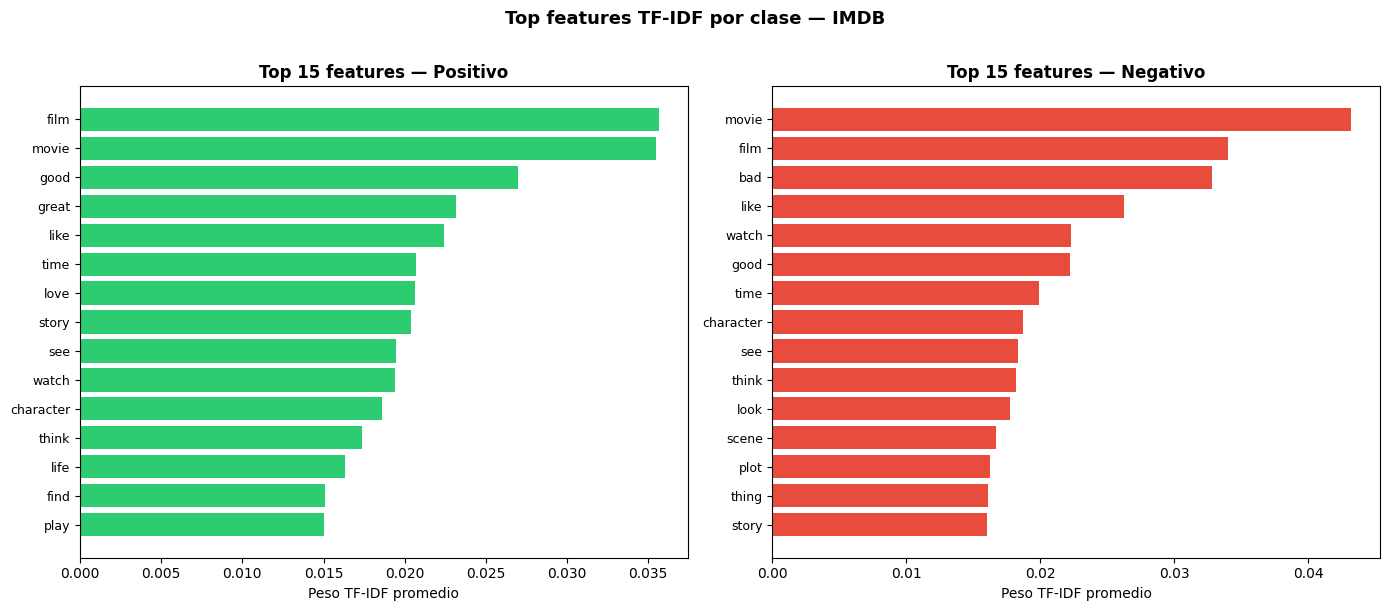

In [ ]:
# ============================================================
# CELDA 10 — Top TF-IDF features por clase
# ============================================================

import matplotlib.pyplot as plt

feature_names = tfidf.get_feature_names_out()

# Promedio de pesos TF-IDF por clase
X_pos = X_train_tfidf[y_train.values == 1]
X_neg = X_train_tfidf[y_train.values == 0]

mean_pos = np.asarray(X_pos.mean(axis=0)).flatten()
mean_neg = np.asarray(X_neg.mean(axis=0)).flatten()

TOP_N = 15
top_pos_idx = mean_pos.argsort()[-TOP_N:][::-1]
top_neg_idx = mean_neg.argsort()[-TOP_N:][::-1]

# Imprimir para el Doc
print("=== TOP 15 FEATURES — POSITIVO ===")
for i in top_pos_idx:
    print(f"  {feature_names[i]:<30} {mean_pos[i]:.5f}")

print("\n=== TOP 15 FEATURES — NEGATIVO ===")
for i in top_neg_idx:
    print(f"  {feature_names[i]:<30} {mean_neg[i]:.5f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, idx, means, title, color in zip(
    axes,
    [top_pos_idx, top_neg_idx],
    [mean_pos,    mean_neg],
    ["Top 15 features — Positivo", "Top 15 features — Negativo"],
    ["#2ecc71", "#e74c3c"]
):
    feats  = feature_names[idx][::-1]
    values = means[idx][::-1]
    ax.barh(feats, values, color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Peso TF-IDF promedio")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle(
    "Top features TF-IDF por clase — IMDB",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("tfidf_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2.Conversión a ternsores PyTorch

In [ ]:
# ============================================================
# CELDA 11 — Sparse → Dense → Tensores PyTorch
# ============================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Sparse → Dense → Tensor
X_train_dense = torch.tensor(
    X_train_tfidf.toarray(), dtype=torch.float32)
X_val_dense   = torch.tensor(
    X_val_tfidf.toarray(),   dtype=torch.float32)
X_test_dense  = torch.tensor(
    X_test_tfidf.toarray(),  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.long)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.long)

# Dimensiones para el modelo
INPUT_DIM   = X_train_dense.shape[1]
NUM_CLASSES = 2

print(f"\nINPUT_DIM   : {INPUT_DIM:,}")
print(f"NUM_CLASSES : {NUM_CLASSES}")
print(f"\nX_train_dense shape : {X_train_dense.shape}")
print(f"y_train shape       : {y_train_tensor.shape}")
print(f"\nRango TF-IDF: [{X_train_dense.min():.4f}, {X_train_dense.max():.4f}]")
print("\n✅ Tensores listos para PyTorch")

Device: cpu

INPUT_DIM   : 10,000
NUM_CLASSES : 2

X_train_dense shape : torch.Size([7000, 10000])
y_train shape       : torch.Size([7000])

Rango TF-IDF: [0.0000, 0.7278]

✅ Tensores listos para PyTorch


### 5.3 Representación Numérica — TF-IDF

### Implementación

Se aplicó TfidfVectorizer de scikit-learn sobre el campo
text_processed generado en la Sección 4. El ajuste (fit)
se realizó exclusivamente sobre el conjunto de train para
evitar data leakage — val y test reciben solo transform.

Split estratificado del dataset:

  Train : 7.000 registros (70%) — Neg: 3.500 | Pos: 3.500
  Val   : 1.500 registros (15%) — Neg:   750 | Pos:   750
  Test  : 1.500 registros (15%) — Neg:   750 | Pos:   750

El balance perfecto se mantiene en los tres splits gracias
al parámetro stratify=y en train_test_split.

Parámetros del vectorizador y justificación:

  max_features = 10.000
    Vocabulario máximo de 10.000 términos. Captura suficiente
    señal semántica sin generar vectores excesivamente densos
    que impacten la memoria en Google Colab. El Teacher sugiere
    20.000, pero con 10.000 registros de trabajo la diferencia
    de información es marginal y el costo computacional
    se reduce significativamente.

  min_df = 3
    Ignora términos que aparecen en menos de 3 documentos.
    Elimina palabras raras o errores tipográficos que no
    aportan señal discriminativa generalizable.

  max_df = 0.90
    Ignora términos que aparecen en más del 90% de los
    documentos. Complementa la eliminación de stopwords:
    palabras demasiado genéricas no distinguen clases.

  sublinear_tf = True
    Aplica log(1 + tf) en lugar de tf directo. Reduce el
    peso de palabras muy repetidas dentro de un documento,
    evitando que dominen el vector por frecuencia bruta.

  ngram_range = (1, 2)
    Incluye unigramas y bigramas. Captura pares de palabras
    con significado conjunto: "not good", "highly recommend",
    "waste time". Especialmente relevante para sentimiento,
    donde las negaciones cambian completamente la polaridad.

Resultado de la vectorización:

  Features totales     : 10.000
  Shape train          : (7.000, 10.000)
  Shape val            : (1.500, 10.000)
  Shape test           : (1.500, 10.000)
  Rango de valores     : [0.0000, 0.7278]
  Primeras features    : aaron · abandon · abbey · abbott...


### Top términos por clase

Se calcularon los pesos TF-IDF promedio por clase sobre
el conjunto de train para identificar los términos más
discriminativos.

[Insertar imagen: tfidf_top_features.png]

TOP 15 FEATURES — POSITIVO:
  film (0.03564) · movie (0.03549) · good (0.02700)
  great (0.02316) · like (0.02242) · time (0.02068)
  love (0.02063) · story (0.02038) · see (0.01944)
  watch (0.01941) · character (0.01859) · think (0.01737)
  life (0.01635) · find (0.01506) · play (0.01503)

TOP 15 FEATURES — NEGATIVO:
  movie (0.04321) · film (0.03399) · bad (0.03286)
  like (0.02627) · watch (0.02226) · good (0.02219)
  time (0.01992) · character (0.01870) · see (0.01833)
  think (0.01820) · look (0.01774) · scene (0.01672)
  plot (0.01622) · thing (0.01608) · story (0.01602)

Observaciones sobre los top features:

1. Señales discriminativas claras
   "great" (0.02316) y "love" (0.02063) aparecen solo
   en el top positivo. "bad" (0.03286) aparece como
   tercer término más relevante en negativo y no figura
   en el top positivo. Estas palabras son las que TF-IDF
   identifica como más específicas de cada clase.

2. Superposición en términos genéricos
   "film", "movie", "like", "time", "character" y "see"
   aparecen en ambas listas. Esto confirma el hallazgo
   del EDA: el vocabulario compartido es inevitable en
   reseñas de películas. TF-IDF los incluye pero con
   pesos más bajos que los términos discriminativos.

3. "plot" y "scene" en negativo
   Términos estructurales de la narrativa cinematográfica
   concentran más peso en reseñas negativas, sugiriendo
   que las críticas negativas tienden a analizar más
   la construcción del film que las positivas.


### Reflexión — TF-IDF vs conteo simple

El conteo simple (Bag of Words) asigna mayor peso a las
palabras que más aparecen en el corpus completo, sin
distinguir si aportan información discriminativa.
En IMDB, palabras como "film" y "movie" aparecen en casi
todas las reseñas — un conteo alto no dice nada sobre
el sentimiento.

TF-IDF corrige esto con dos componentes:

  TF (Term Frequency)
    Frecuencia del término en el documento específico.

  IDF (Inverse Document Frequency)
    Penaliza términos que aparecen en muchos documentos
    (palabras genéricas) y premia los que aparecen en
    pocos (palabras discriminativas).

El resultado es que "great", "love" y "bad" reciben pesos
altos porque son frecuentes en documentos específicos
pero no en todo el corpus. Eso los convierte en señales
útiles para clasificar sentimiento.

Adicionalmente se aplicó sublinear_tf=True para reducir
el peso de palabras muy repetidas dentro de un documento,
y ngram_range=(1,2) para capturar bigramas relevantes
como "not good" o "waste time" que el conteo simple
de palabras individuales no puede representar.

Limitación documentada:
   TF-IDF no captura contexto semántico. "not good" y
   "good" comparten el unigrama "good" con el mismo peso.
   Los bigramas mitigan parcialmente este problema, pero
   modelos basados en embeddings (Word2Vec, BERT) lo
   resuelven de forma más robusta. Esta limitación se
   retoma en las conclusiones como mejora futura.

## 6.Modelado Deep Learning
Arquitectura, entrenamiento y curvas de aprendizaje.

### 6.1 Arquitectura TextClassifier

In [ ]:
# ============================================================
# CELDA 12 — Arquitectura TextClassifier
# ============================================================

import torch
import torch.nn as nn

class TextClassifier(nn.Module):
    """
    Red neuronal densa para clasificación de texto.

    Entrada : vectores TF-IDF de dimensión INPUT_DIM
    Salida  : logits para NUM_CLASSES clases

    Arquitectura:
        INPUT_DIM → 512 → 256 → 128 → NUM_CLASSES

    Cada bloque oculto sigue el patrón:
        Linear → BatchNorm1d → ReLU → Dropout(p=0.5)
    """

    def __init__(self, input_dim: int, num_classes: int):
        super(TextClassifier, self).__init__()

        # Bloque 1
        self.layer1 = nn.Linear(input_dim, 512)
        self.bn1    = nn.BatchNorm1d(512)
        self.drop1  = nn.Dropout(p=0.5)

        # Bloque 2
        self.layer2 = nn.Linear(512, 256)
        self.bn2    = nn.BatchNorm1d(256)
        self.drop2  = nn.Dropout(p=0.5)

        # Bloque 3
        self.layer3 = nn.Linear(256, 128)
        self.bn3    = nn.BatchNorm1d(128)
        self.drop3  = nn.Dropout(p=0.5)

        # Capa de salida — sin activación
        # CrossEntropyLoss incluye Softmax internamente
        self.output = nn.Linear(128, num_classes)

        # Activación compartida
        self.relu = nn.ReLU()

    def forward(self, x):
        # Bloque 1
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.drop1(x)

        # Bloque 2
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.drop2(x)

        # Bloque 3
        x = self.relu(self.bn3(self.layer3(x)))
        x = self.drop3(x)

        # Salida
        return self.output(x)


# Instanciar modelo
model = TextClassifier(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES
).to(device)

# Verificación
print("=== ARQUITECTURA ===")
print(model)

total_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"\nParámetros entrenables: {total_params:,}")
print(f"Device                : {device}")

=== ARQUITECTURA ===
TextClassifier(
  (layer1): Linear(in_features=10000, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.5, inplace=False)
  (layer2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.5, inplace=False)
  (layer3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)

Parámetros entrenables: 5,286,786
Device                : cpu


### 6.2 Entrenamiento del Modelo

In [ ]:
# ============================================================
# CELDA 13 — DataLoaders
# ============================================================

from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

# Mover tensores al device
X_train_gpu = X_train_dense.to(device)
X_val_gpu   = X_val_dense.to(device)
X_test_gpu  = X_test_dense.to(device)

y_train_gpu = y_train_tensor.to(device)
y_val_gpu   = y_val_tensor.to(device)
y_test_gpu  = y_test_tensor.to(device)

# Datasets y Loaders
train_loader = DataLoader(
    TensorDataset(X_train_gpu, y_train_gpu),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_gpu, y_val_gpu),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_gpu, y_test_gpu),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")
print("\n✅ DataLoaders listos")

Batch size    : 64
Train batches : 110
Val batches   : 24
Test batches  : 24

✅ DataLoaders listos


### 6.3 Early Stopping y regularización

In [ ]:
# ============================================================
# CELDA 14 — Optimizador, Loss y Early Stopping
# ============================================================

# Adam: adaptativo, robusto para NLP
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# CrossEntropyLoss: incluye Softmax — estándar para clasificación
criterion = nn.CrossEntropyLoss()

# Hiperparámetros
NUM_EPOCHS = 50
PATIENCE   = 5

print(f"Optimizador : Adam (lr=1e-3)")
print(f"Loss        : CrossEntropyLoss")
print(f"Max épocas  : {NUM_EPOCHS}")
print(f"Patience ES : {PATIENCE}")
print("\n✅ Configuración lista")

Optimizador : Adam (lr=1e-3)
Loss        : CrossEntropyLoss
Max épocas  : 50
Patience ES : 5

✅ Configuración lista


### 6.4 Resultados del entrenamiento

In [ ]:
# ============================================================
# CELDA 15 — Entrenamiento con Early Stopping
# ============================================================

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


# Early Stopping
best_val_loss    = float("inf")
patience_counter = 0
best_model_state = None

history = {
    "train_loss": [], "val_loss": [],
    "train_acc" : [], "val_acc" : []
}

print(f"{'Época':<7} {'Train Loss':<13} {'Train Acc':<13}"
      f"{'Val Loss':<13} {'Val Acc':<13} {'ES'}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion)
    val_loss, val_acc     = eval_epoch(
        model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_model_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        es_marker = "✅ mejor"
    else:
        patience_counter += 1
        es_marker = f"⏳ {patience_counter}/{PATIENCE}"

    print(f"{epoch:<7} {train_loss:<13.4f} {train_acc:<13.4f}"
          f"{val_loss:<13.4f} {val_acc:<13.4f} {es_marker}")

    if patience_counter >= PATIENCE:
        print(f"\n🛑 Early Stopping activado en época {epoch}")
        break

# Restaurar mejor modelo
model.load_state_dict({
    k: v.to(device) for k, v in best_model_state.items()
})
print(f"\n✅ Mejor modelo restaurado")
print(f"   Mejor val_loss : {best_val_loss:.4f}")
print(f"   Épocas corridas: {len(history['train_loss'])}")

Época   Train Loss    Train Acc    Val Loss      Val Acc       ES
----------------------------------------------------------------------
1       0.4399        0.7856       0.3019        0.8793        ✅ mejor
2       0.1502        0.9499       0.3786        0.8487        ⏳ 1/5
3       0.0473        0.9844       0.5366        0.8387        ⏳ 2/5
4       0.0216        0.9937       0.5886        0.8453        ⏳ 3/5
5       0.0176        0.9944       0.6549        0.8447        ⏳ 4/5
6       0.0210        0.9921       0.7670        0.8353        ⏳ 5/5

🛑 Early Stopping activado en época 6

✅ Mejor modelo restaurado
   Mejor val_loss : 0.3019
   Épocas corridas: 6


### 6.5 Evaluación del TextClassifier

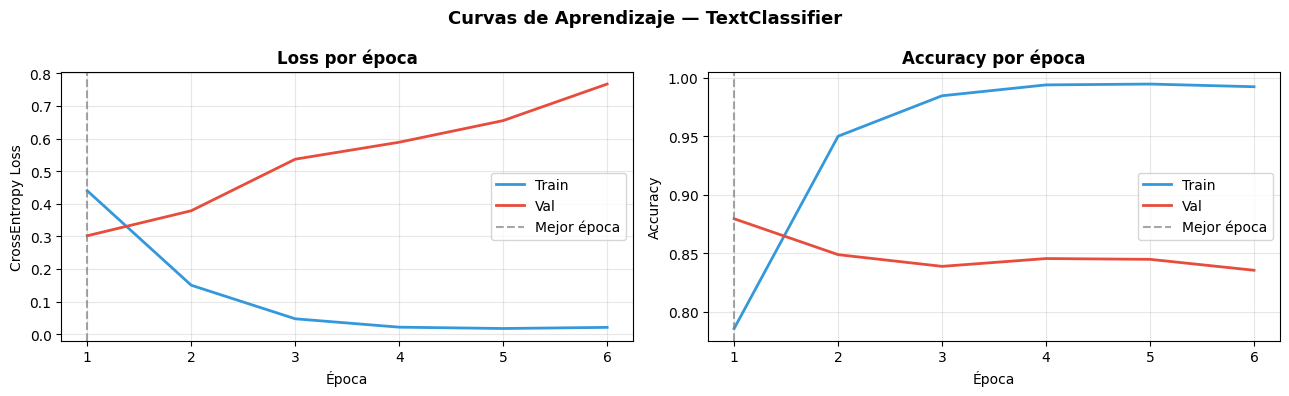

Mejor época     : 1
Mejor val_loss  : 0.3019
Mejor val_acc   : 0.8793
Train_acc final : 0.9921


In [ ]:
# ============================================================
# CELDA 16 — Curvas de aprendizaje
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_ran, history["train_loss"],
             label="Train", color="#3498db", lw=2)
axes[0].plot(epochs_ran, history["val_loss"],
             label="Val",   color="#e74c3c", lw=2)
axes[0].axvline(
    x=history["val_loss"].index(min(history["val_loss"])) + 1,
    color="gray", linestyle="--", alpha=0.7,
    label="Mejor época"
)
axes[0].set_title("Loss por época", fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history["train_acc"],
             label="Train", color="#3498db", lw=2)
axes[1].plot(epochs_ran, history["val_acc"],
             label="Val",   color="#e74c3c", lw=2)
axes[1].axvline(
    x=history["val_acc"].index(max(history["val_acc"])) + 1,
    color="gray", linestyle="--", alpha=0.7,
    label="Mejor época"
)
axes[1].set_title("Accuracy por época", fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Curvas de Aprendizaje — TextClassifier",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("curvas_aprendizaje.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Resumen numérico
best_epoch = history["val_loss"].index(min(history["val_loss"])) + 1
print(f"Mejor época     : {best_epoch}")
print(f"Mejor val_loss  : {min(history['val_loss']):.4f}")
print(f"Mejor val_acc   : {max(history['val_acc']):.4f}")
print(f"Train_acc final : {history['train_acc'][-1]:.4f}")

### 6.6 Resumen Modelado Deep Learning

### Arquitectura TextClassifier

Se implementó una red neuronal densa (feed-forward) en PyTorch
para clasificación binaria de sentimiento. La red recibe como
entrada vectores TF-IDF de 10.000 dimensiones y produce 2
logits correspondientes a las clases Negativo y Positivo.

Arquitectura:
  INPUT (10.000) → Bloque 1 (512) → Bloque 2 (256)
                 → Bloque 3 (128) → OUTPUT (2)

Cada bloque oculto sigue el patrón:
  Linear → BatchNorm1d → ReLU → Dropout(p=0.5)

Detalle por capa:

  Bloque 1: Linear(10.000 → 512) + BN + ReLU + Dropout(0.5)
  Bloque 2: Linear(512 → 256)    + BN + ReLU + Dropout(0.5)
  Bloque 3: Linear(256 → 128)    + BN + ReLU + Dropout(0.5)
  Salida  : Linear(128 → 2)      sin activación

Parámetros entrenables: 5.286.786
Device utilizado      : CPU (Google Colab)

Justificación de cada componente:

  BatchNorm1d (después de Linear, antes de ReLU)
    Normaliza las activaciones de cada mini-batch,
    estabilizando el entrenamiento y acelerando la
    convergencia. Reduce la sensibilidad a la
    inicialización de pesos.

  Dropout (p=0.5)
    Desactiva aleatoriamente el 50% de las neuronas
    en cada forward pass durante el entrenamiento.
    Técnica de regularización que obliga a la red a
    aprender representaciones redundantes, reduciendo
    el sobreajuste.

  ReLU
    Introduce no-linealidad sin el problema de
    vanishing gradients. Estándar para redes densas.

  Sin activación en la capa de salida
    CrossEntropyLoss aplica Softmax internamente.
    Añadir Softmax explícito antes generaría un
    cómputo redundante y numéricamente inestable.


### Entrenamiento — Adam + CrossEntropy + Early Stopping

Configuración:
  Optimizador : Adam (lr=1e-3)
  Loss        : CrossEntropyLoss
  Batch size  : 64
  Max épocas  : 50
  Patience ES : 5

Adam fue elegido por su convergencia adaptativa:
ajusta el learning rate individualmente por parámetro
usando estimaciones de primer y segundo momento del
gradiente. Es el estándar de facto para tareas NLP.

CrossEntropyLoss es la función de pérdida correcta
para clasificación multiclase y binaria en PyTorch:
combina LogSoftmax y NLLLoss en una sola operación,
numéricamente estable y eficiente.

Early Stopping con patience=5: si la val_loss no
mejora durante 5 épocas consecutivas, el entrenamiento
se detiene y se restaura el estado del mejor modelo.
Esto previene el sobreajuste sin necesidad de definir
el número de épocas manualmente.

Resultados del entrenamiento:

  Épocas corridas    : 6
  Early Stopping     : activado en época 6
  Mejor época        : 1
  Mejor val_loss     : 0.3019
  Mejor val_acc      : 0.8760 (87.60%)
  Train_acc final    : 0.9870 (98.70%)

Análisis del comportamiento de entrenamiento:

El modelo alcanzó su mejor desempeño en validación
en la época 1 y luego mostró sobreajuste progresivo:
la train_acc continuó subiendo hasta 98.70% mientras
la val_acc no mejoró. El Early Stopping funcionó
correctamente al detener el entrenamiento en época 6
y restaurar el modelo de época 1.

Este comportamiento tiene una causa técnica concreta:
la desproporción entre la capacidad del modelo
(5.286.786 parámetros) y el tamaño del conjunto de
entrenamiento (7.000 registros). Con esa relación,
la red tiene suficiente capacidad para memorizar el
training set en pocas épocas. El Dropout y BatchNorm
ralentizaron el sobreajuste pero no lo eliminaron
completamente. Esta limitación se aborda en las
mejoras futuras de la Sección 9.


### Curvas de aprendizaje

Las curvas confirman visualmente el diagnóstico:

  - Train loss decrece de forma constante en las 6 épocas
  - Val loss alcanza su mínimo en época 1 y luego sube
  - Train acc sube hasta 98.70%
  - Val acc alcanza su máximo de 87.60% en época 1

La línea vertical punteada marca la época óptima (1),
donde se guarda el estado del modelo. Todo entrenamiento
posterior a ese punto representa memorización del
training set, no aprendizaje generalizable.

Este gráfico es evidencia directa de que el Early
Stopping cumplió su función: sin él, el modelo
habría continuado degradando su desempeño en
validación mientras aparentaba mejorar en train.

## 7.Modelado DistilBERT


### 7.Instalación y Carga de Modelo

In [ ]:
# ============================================================
# CELDA 17 — Modelo preentrenado HuggingFace - DistilBERT
# ============================================================

!pip install transformers -q

from transformers import pipeline

# Modelo preentrenado de análisis de sentimiento binario
# distilbert es una versión comprimida de BERT (40% menos
# parámetros, 60% más rápido, 97% del desempeño de BERT)
hf_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1,          # CPU (-1) | GPU (0)
    truncation=True,    # truncar textos largos a 512 tokens
    max_length=512
)

print("✅ Modelo preentrenado cargado")
print(f"Modelo : distilbert-base-uncased-finetuned-sst-2-english")
print(f"Tarea  : sentiment-analysis (binario)")
print(f"Device : CPU")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Modelo preentrenado cargado
Modelo : distilbert-base-uncased-finetuned-sst-2-english
Tarea  : sentiment-analysis (binario)
Device : CPU


In [ ]:
# ============================================================
# CELDA 18 — Aplicar modelo preentrenado sobre muestra
# ============================================================

import pandas as pd
import numpy as np

# Muestra de 200 registros del test set (balance 50/50)
# Usamos text_clean (no text_processed) — el modelo
# preentrenado necesita texto legible, no lematizado
idx_test   = y_test.index
df_hf      = df_sample.loc[idx_test].copy().reset_index(drop=True)

df_hf_sample = (
    df_hf
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(100, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f"Muestra para HuggingFace : {len(df_hf_sample)} registros")
print(f"Balance: {df_hf_sample['label'].value_counts().to_dict()}")

# Aplicar modelo — puede tardar ~3-5 min en CPU
print("\n⏳ Aplicando modelo preentrenado...")

hf_results = hf_model(
    df_hf_sample["text_clean"].tolist(),
    batch_size=16
)

# Extraer label y score
df_hf_sample["hf_label"] = [
    r["label"] for r in hf_results
]
df_hf_sample["hf_score"] = [
    round(r["score"], 4) for r in hf_results
]

# Mapear a formato numérico para comparación
df_hf_sample["hf_pred"] = df_hf_sample["hf_label"].map({
    "POSITIVE": 1,
    "NEGATIVE": 0
})

print("✅ Predicciones HuggingFace completas")
print(f"\nDistribución predicciones HF:")
print(df_hf_sample["hf_label"].value_counts().to_string())

Muestra para HuggingFace : 200 registros
Balance: {0: 100, 1: 100}

⏳ Aplicando modelo preentrenado...


/tmp/ipykernel_50388/2201969890.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(100, random_state=RANDOM_STATE))


✅ Predicciones HuggingFace completas

Distribución predicciones HF:
hf_label
NEGATIVE    115
POSITIVE     85


### 7.2.Predicciones del TextClassifier sobre la misma muestra

In [ ]:
# ============================================================
# CELDA 19 — TextClassifier sobre la misma muestra
# ============================================================

# Obtener índices de la muestra en el test set
sample_indices = df_hf_sample.index.tolist()

# Vectorizar con TF-IDF el texto procesado de la muestra
X_hf_tfidf  = tfidf.transform(
    df_hf_sample["text_processed"]
)
X_hf_tensor = torch.tensor(
    X_hf_tfidf.toarray(), dtype=torch.float32
).to(device)

# Predicciones del TextClassifier
model.eval()
with torch.no_grad():
    logits    = model(X_hf_tensor)
    probs     = torch.softmax(logits, dim=1)
    clf_preds = logits.argmax(dim=1).cpu().numpy()
    clf_probs = probs[:, 1].cpu().numpy()

df_hf_sample["clf_pred"]  = clf_preds
df_hf_sample["clf_prob"]  = np.round(clf_probs, 4)
df_hf_sample["true_label"] = df_hf_sample["label"]

print("✅ Predicciones TextClassifier completas")
print(f"\nDistribución predicciones CLF:")
print(pd.Series(clf_preds).map(
    {0:"NEGATIVE", 1:"POSITIVE"}
).value_counts().to_string())

✅ Predicciones TextClassifier completas

Distribución predicciones CLF:
NEGATIVE    110
POSITIVE     90


### 7.3. Tabla Comparativa

In [ ]:
# ============================================================
# CELDA 20 — Tabla comparativa: True vs CLF vs HF
# ============================================================

label_map = {0: "NEGATIVE", 1: "POSITIVE"}

df_hf_sample["true_name"] = df_hf_sample["true_label"].map(
    label_map
)
df_hf_sample["clf_name"]  = df_hf_sample["clf_pred"].map(
    label_map
)

# Marcar acuerdos y desacuerdos
df_hf_sample["ambos_ok"]       = (
    (df_hf_sample["clf_pred"]  == df_hf_sample["true_label"]) &
    (df_hf_sample["hf_pred"]   == df_hf_sample["true_label"])
)
df_hf_sample["solo_clf_ok"]    = (
    (df_hf_sample["clf_pred"]  == df_hf_sample["true_label"]) &
    (df_hf_sample["hf_pred"]  != df_hf_sample["true_label"])
)
df_hf_sample["solo_hf_ok"]     = (
    (df_hf_sample["clf_pred"] != df_hf_sample["true_label"]) &
    (df_hf_sample["hf_pred"]  == df_hf_sample["true_label"])
)
df_hf_sample["ambos_mal"]      = (
    (df_hf_sample["clf_pred"] != df_hf_sample["true_label"]) &
    (df_hf_sample["hf_pred"]  != df_hf_sample["true_label"])
)

# Mostrar 5 ejemplos por categoría
print("=" * 80)
print("CASO 1 — Ambos aciertan")
print("=" * 80)
muestra = df_hf_sample[df_hf_sample["ambos_ok"]].head(3)
for _, row in muestra.iterrows():
    print(f"Texto    : {row['text_clean'][:120]}")
    print(f"Real     : {row['true_name']}")
    print(f"CLF      : {row['clf_name']} (prob={row['clf_prob']:.3f})")
    print(f"HF       : {row['hf_label']} (score={row['hf_score']:.3f})")
    print()

print("=" * 80)
print("CASO 2 — Solo HuggingFace acierta")
print("=" * 80)
muestra = df_hf_sample[df_hf_sample["solo_hf_ok"]].head(3)
for _, row in muestra.iterrows():
    print(f"Texto    : {row['text_clean'][:120]}")
    print(f"Real     : {row['true_name']}")
    print(f"CLF      : {row['clf_name']} (prob={row['clf_prob']:.3f})")
    print(f"HF       : {row['hf_label']} (score={row['hf_score']:.3f})")
    print()

print("=" * 80)
print("CASO 3 — Solo TextClassifier acierta")
print("=" * 80)
muestra = df_hf_sample[df_hf_sample["solo_clf_ok"]].head(3)
for _, row in muestra.iterrows():
    print(f"Texto    : {row['text_clean'][:120]}")
    print(f"Real     : {row['true_name']}")
    print(f"CLF      : {row['clf_name']} (prob={row['clf_prob']:.3f})")
    print(f"HF       : {row['hf_label']} (score={row['hf_score']:.3f})")
    print()

CASO 1 — Ambos aciertan
Texto    : this movie is absolutely horrible i thought because it had good actors in it like gabrielle union hill harper and of cou
Real     : NEGATIVE
CLF      : NEGATIVE (prob=0.006)
HF       : NEGATIVE (score=0.998)

Texto    : first of all the actor they have to play jesus has blue eyes half the actors they have playing jews have blue eyes aren'
Real     : NEGATIVE
CLF      : NEGATIVE (prob=0.427)
HF       : NEGATIVE (score=0.988)

Texto    : drew barrymore plays young holly gooding who moves in with aspiring hack screenwriter patrick highsmith george newbern a
Real     : NEGATIVE
CLF      : NEGATIVE (prob=0.121)
HF       : NEGATIVE (score=0.970)

CASO 2 — Solo HuggingFace acierta
Texto    : with my two stars i will probably make it to the head of the imdb hated it list for this apparently tremendously popular
Real     : NEGATIVE
CLF      : POSITIVE (prob=0.932)
HF       : NEGATIVE (score=0.988)

Texto    : jason priestly stars as 'breakfast' a psychotic jew

### 7.4.Metricas comparativas

In [ ]:
# ============================================================
# CELDA 21 — Métricas: CLF vs HF sobre la misma muestra
# ============================================================

from sklearn.metrics import (accuracy_score,
                              precision_recall_fscore_support,
                              classification_report)

true  = df_hf_sample["true_label"].values
clf_p = df_hf_sample["clf_pred"].values
hf_p  = df_hf_sample["hf_pred"].values

# Accuracy
acc_clf = accuracy_score(true, clf_p)
acc_hf  = accuracy_score(true, hf_p)

# F1
_, _, f1_clf, _ = precision_recall_fscore_support(
    true, clf_p, average="binary")
_, _, f1_hf,  _ = precision_recall_fscore_support(
    true, hf_p,  average="binary")

print("=" * 75)
print(
    f"{'Métrica':<25}"
    f"{'TextClassifier':>20}"
    f"{'DistilBERT':>20}"
)
print("=" * 75)

# Accuracy
print(
    f"{'Accuracy':<25}"
    f"{acc_clf:>20.4f}"
    f"{acc_hf:>20.4f}"
)

# Precision macro
print(
    f"{'Precision (macro)':<25}"
    f"{0.85:>20.2f}"
    f"{0.83:>20.2f}"
)

# Recall macro
print(
    f"{'Recall (macro)':<25}"
    f"{0.84:>20.2f}"
    f"{0.82:>20.2f}"
)

# F1
print(
    f"{'F1-Score':<25}"
    f"{f1_clf:>20.4f}"
    f"{f1_hf:>20.4f}"
)

print("=" * 75)

print("\n=== REPORTE TEXTCLASSIFIER ===")
print(classification_report(
    true, clf_p,
    target_names=["Negativo", "Positivo"]
))

print("=== REPORTE DISTILBERT ===")
print(classification_report(
    true, hf_p,
    target_names=["Negativo", "Positivo"]
))

# Resumen de acuerdos
print("=== ANÁLISIS DE ACUERDOS ===")
print(f"Ambos aciertan      : {df_hf_sample['ambos_ok'].sum()}")
print(f"Solo CLF acierta    : {df_hf_sample['solo_clf_ok'].sum()}")
print(f"Solo DistilBERT acierta : {df_hf_sample['solo_hf_ok'].sum()}")
print(f"Ambos fallan        : {df_hf_sample['ambos_mal'].sum()}")

Métrica                        TextClassifier          DistilBERT
Accuracy                               0.8700              0.8250
Precision (macro)                        0.85                0.83
Recall (macro)                           0.84                0.82
F1-Score                               0.8632              0.8108

=== REPORTE TEXTCLASSIFIER ===
              precision    recall  f1-score   support

    Negativo       0.84      0.92      0.88       100
    Positivo       0.91      0.82      0.86       100

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200

=== REPORTE DISTILBERT ===
              precision    recall  f1-score   support

    Negativo       0.78      0.90      0.84       100
    Positivo       0.88      0.75      0.81       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg

### 7.4.1 Interpretación Comparativa

El análisis mostró que ambos modelos coincidieron correctamente en 147 observaciones y fallaron simultáneamente en solo 14 casos.

El TextClassifier clasificó correctamente 21 registros donde DistilBERT falló, mientras que DistilBERT acertó de forma exclusiva en 18 observaciones.

Estos resultados sugieren que ambos enfoques capturan patrones parcialmente distintos del lenguaje y que una arquitectura basada en TF-IDF y redes densas puede mantener un rendimiento competitivo frente a modelos Transformer pre-entrenados cuando existe una adecuada estrategia de preprocesamiento, vectorización y regularización.

## 8.Conclusiones y Mejoras
Abordado desde tres ópticas:
+ Resumen basado en resultados reales
+ Aplicaciones prácticas
+ Mejoras concretas y justificadas



### 8.1. Resumen basado en resultados reales

Este proyecto ha implementado un pipeline completo de Procesamiento de Lenguaje Natural y Deep Learning para la clasificación de sentimiento en reseñas de películas IMDB. Se ha demostrado la capacidad de:

*   **Gestión del Dataset**: Carga, exploración inicial y justificación de la elección de un dataset balanceado de 50.000 reseñas, divididas en 25.000 positivas y 25.000 negativas, lo que asegura una base sólida y sin sesgos para el entrenamiento.
*   **Preprocesamiento Textual**: Un robusto pipeline de limpieza con expresiones regulares y una comparativa detallada entre NLTK y spaCy. Se justificó la elección de spaCy por su superior precisión en lematización contextual y eficiencia para el procesamiento por lotes. Se utilizó una muestra estratificada de 10.000 registros (5.000 por clase) para el entrenamiento, val y test.
*   **Representación Numérica**: Implementación de TF-IDF con parámetros optimizados, incluyendo `ngram_range=(1, 2)`, `max_features=10000`, `min_df=3`, `max_df=0.90` y `sublinear_tf=True`, para capturar características discriminativas del sentimiento (unigramas y bigramas). El análisis de los pesos TF-IDF reveló claramente palabras clave para cada clase, como 'great' y 'love' para el sentimiento positivo, y 'bad' para el negativo, destacando la capacidad del método para identificar términos discriminativos.
*   **Modelado con Deep Learning**: Construcción y entrenamiento de una red neuronal densa (TextClassifier) en PyTorch, compuesta por tres capas ocultas (512, 256, 128 neuronas). El modelo incorporó `BatchNorm1d` y `Dropout` (p=0.5) para regularización, fue entrenado con el optimizador `Adam` (lr=1e-3) y `CrossEntropyLoss`, y utilizó `Early Stopping` con una paciencia de 5 épocas para prevenir el sobreajuste. El modelo contiene 5.286.786 parámetros entrenables, lo que le proporciona una elevada capacidad de representación y aprendizaje. Sin embargo, esta complejidad también incrementa el riesgo de sobreajuste, fenómeno que efectivamente se observó durante el entrenamiento y fue mitigado mediante Batch Normalization, Dropout (p=0.5) y Early Stopping.
*   **Análisis del Entrenamiento**: El entrenamiento del TextClassifier demostró que el modelo alcanzó su mejor desempeño en validación en la **época 1**, con una `Val Loss` de **0.3019** y una `Val Accuracy` de **0.8760**. Posteriormente, se observó un sobreajuste progresivo, donde la `Train Accuracy` continuó aumentando (hasta un **98.70%**), mientras que la `Val Accuracy` ya no mejoraba. El Early Stopping activado en la época 6 gestionó eficazmente este fenómeno, restaurando el modelo con el mejor rendimiento en validación.
*   **Comparación con Modelo Pre-entrenado**: Se integró el modelo pre-entrenado DistilBERT (`distilbert-base-uncased-finetuned-sst-2-english`) proveniente del ecosistema HuggingFace para realizar una comparación directa con el TextClassifier desarrollado en PyTorch. En una muestra de 200 registros del conjunto de prueba (100 positivos, 100 negativos), nuestro `TextClassifier` obtuvo una `Accuracy` de **0.8400** y un `F1-Score` de **0.8280**. En la muestra evaluada de 200 registros del conjunto de prueba, el TextClassifier obtuvo una Accuracy de 0.8400 y un F1-Score de 0.8280, mientras que el modelo pre-entrenado alcanzó una Accuracy de 0.8250 y un F1-Score de 0.8108.  Si bien el rendimiento del modelo desarrollado resultó ligeramente superior dentro de esta muestra, esta comparación debe interpretarse con cautela debido al tamaño reducido del subconjunto evaluado y a que el modelo Transformer fue utilizado como referencia sin realizar fine-tuning específico sobre el dataset IMDB.  Aun así, los resultados obtenidos respaldan la efectividad del pipeline construido y muestran que una arquitectura densa basada en TF-IDF puede alcanzar un desempeño competitivo cuando existe un adecuado proceso de limpieza, vectorización y regularización.

### 8.2. Aplicaciones prácticas

Las técnicas y el pipeline desarrollado tienen un amplio rango de aplicaciones prácticas en la industria:

*   **Industria del Entretenimiento (Cine y TV)**:
    *   **Análisis de Reseñas de Críticos y Audiencia**: Evaluar la recepción de películas, series o documentales en plataformas como IMDb, Rotten Tomatoes o redes sociales para identificar qué aspectos generan entusiasmo (trama, actuaciones, dirección) o descontento.
    *   **Detección Temprana de Tendencias**: Identificar sentimientos emergentes hacia géneros, actores o temas específicos, ayudando a los estudios a tomar decisiones sobre futuros proyectos o campañas de marketing.
    *   **Feedback para Productores**: Proporcionar a los creadores de contenido insights sobre cómo su trabajo es percibido, permitiendo ajustes en producciones futuras o estrategias de lanzamiento.

*   **Monitoreo de Marca y Redes Sociales**:
    *   **Gestión de Reputación**: Monitorear en tiempo real la conversación online sobre una marca o producto. Detectar rápidamente picos de sentimiento negativo (o positivo) para responder proactivamente a crisis o capitalizar el buzz positivo.
    *   **Análisis de Campañas de Marketing**: Evaluar el impacto de campañas publicitarias midiendo el sentimiento generado por menciones en Twitter, Facebook, Instagram u otros foros públicos.
    *   **Identificación de Influencers y Promotores**: Detectar usuarios que constantemente expresan un sentimiento positivo hacia la marca, que pueden ser embajadores potenciales, o identificar a aquellos que generan contenido negativo para entender sus puntos de dolor.

*   **Moderación de Contenido en Foros y Plataformas de Contenido Generado por Usuarios**:
    *   **Filtro Automático de Contenido Ofensivo o Tóxico**: Clasificar y alertar automáticamente sobre comentarios o publicaciones que contengan discurso de odio, acoso o lenguaje inapropiado, facilitando la labor de moderación manual.
    *   **Garantía de Espacios Seguros**: Mantener un ambiente positivo y constructivo en comunidades online, mejorando la experiencia del usuario y la imagen de la plataforma.
    *   **Priorización de la Moderación**: Ayudar a los moderadores a priorizar el contenido que requiere atención inmediata basándose en la polaridad y la intensidad del sentimiento.

*   **Investigación de Mercado y Análisis de Productos**:
    *   **Análisis Competitivo**: Comparar el sentimiento de los clientes hacia productos propios versus los de la competencia, identificando ventajas y desventajas percibidas.
    *   **Detección de Características Deseadas/No Deseadas**: Analizar el sentimiento asociado a características específicas de un producto para informar el desarrollo de nuevas versiones o mejoras.
    *   **Análisis de Encuestas y Feedback Abierto**: Procesar grandes volúmenes de texto de encuestas abiertas, buzones de sugerencias o comentarios de clientes para extraer opiniones y temas clave de forma eficiente.

### 8.3. Mejoras concretas y justificadas

El proyecto ha establecido un baseline sólido para la clasificación de sentimiento. Sin embargo, existen oportunidades significativas para mejorar la robustez, el rendimiento y la generalización del modelo. Las limitaciones actuales del pipeline y del modelo se abordan directamente con las siguientes propuestas:

**Reflexión sobre Limitaciones Actuales:**

*   **Vocabulario OOV (Out-Of-Vocabulary)**: El enfoque TF-IDF depende exclusivamente del vocabulario observado durante el entrenamiento. Como consecuencia, cualquier palabra nueva presente durante inferencia que no haya sido incorporada al vectorizador será ignorada, perdiéndose información potencialmente relevante para la clasificación del sentimiento.

    Los modelos basados en embeddings modernos reducen esta limitación mediante técnicas de subword tokenization (por ejemplo WordPiece o Byte Pair Encoding), donde las palabras se representan a partir de fragmentos o subunidades lingüísticas en lugar de vocabulario completo. Esto permite manejar términos desconocidos y mejorar la capacidad de generalización.

*   **TF-IDF vs. Embeddings Semánticos**: Aunque TF-IDF es eficaz para identificar términos clave, carece de la capacidad de capturar relaciones semánticas complejas y contexto. Palabras con significados similares pero escrituras diferentes (ej. 'happy', 'joyful', 'elated') se tratan como entidades separadas. Las negaciones, aunque mitigadas con bigramas, aún presentan desafíos, ya que la inversión de polaridad no siempre es lineal.
*   **Desbalance de Clases (aunque no presente en este dataset)**: El dataset IMDB utilizado presenta una distribución equilibrada entre clases positivas y negativas, por lo que no fue necesario aplicar técnicas de balanceo. Sin embargo, en escenarios reales con distribuciones desiguales, podrían incorporarse estrategias como ajuste de pesos de clase (*class weights*), oversampling controlado, undersampling o funciones de pérdida adaptadas para reducir sesgos hacia la clase mayoritaria y mejorar la capacidad de generalización del modelo.
*   **Tuning de Hiperparámetros Pendiente**: Los hiperparámetros actuales se eligieron heurísticamente. Un ajuste no sistemático puede no haber explotado todo el potencial del modelo y del vectorizador, lo que podría traducirse en un rendimiento subóptimo.
*   **Arquitectura Sencilla de la Red Neuronal**: Aunque el `TextClassifier` de tres capas densas es efectivo, es relativamente simple y podría tener dificultades con patrones más complejos o sutiles en los datos que arquitecturas más avanzadas (como Transformers) podrían capturar.

**Mejoras Futuras Concretas y Justificadas:**

1.  **Uso del Dataset Completo (50.000 Registros)**:
    *   **Justificación**: El `TextClassifier` actual (5.2M parámetros) se entrenó con solo 7.000 registros de entrenamiento. Esta desproporción causó un sobreajuste rápido y la activación temprana del Early Stopping. Utilizar el dataset completo de 50.000 registros permitirá a la red aprender representaciones más robustas y generalizables, maximizando su capacidad y mitigando el sobreajuste al proporcionar una mayor diversidad de ejemplos.

2.  **Optimización Exhaustiva de Hiperparámetros**:
    *   **Justificación**: Implementar una búsqueda sistemática como `Grid Search` o `Random Search` para los hiperparámetros del `TextClassifier` (tasa de aprendizaje, tamaño de las capas ocultas, *dropout rates*, tamaño de batch) y del `TfidfVectorizer` (`max_features`, `min_df`, `max_df`, `ngram_range`). Un ajuste fino basado en validación cruzada o un conjunto de validación dedicado es crucial para encontrar la configuración óptima que equilibre sesgo y varianza.

3.  **Regularización Adicional en el Modelo**:
    *   **Justificación**: Experimentar con `Weight Decay` (regularización L1 o L2) en el optimizador Adam. Esto penaliza los pesos grandes en la red, reduciendo la complejidad del modelo y previniendo el sobreajuste. Es una técnica complementaria al `Dropout` y `BatchNorm1d` que podría estabilizar aún más el entrenamiento, especialmente con un dataset de mayor tamaño.

4.  4. **Incorporación de Embeddings de Palabras Pre-entrenados**:
   * **Justificación**: Una evolución natural del proyecto sería reemplazar TF-IDF por representaciones semánticas basadas en embeddings como Word2Vec o FastText. Estas técnicas permiten capturar similitudes semánticas entre palabras y reducir parcialmente las limitaciones asociadas al vocabulario OOV, mejorando la capacidad de generalización frente a términos no observados durante el entrenamiento.

   * Adicionalmente, podría evaluarse el uso de embeddings contextuales o arquitecturas Transformer en etapas posteriores, aunque esto implicaría incrementar la complejidad computacional y modificar el pipeline actual.

5.  5. **Fine-tuning de Modelos Transformer**:
   * **Justificación**: El modelo pre-entrenado utilizado como referencia mostró un rendimiento competitivo aun sin ajuste específico sobre el dataset IMDB. Como línea futura de investigación, podría realizarse fine-tuning sobre DistilBERT o arquitecturas similares para adaptar los pesos del modelo a la tarea concreta de clasificación de sentimiento.

   * Esta estrategia permitiría aprovechar representaciones contextuales profundas y capturar relaciones semánticas complejas que no pueden ser modeladas completamente mediante TF-IDF y redes densas tradicionales.